In [4]:
#Khởi chạy các thư viện
#pip install ta vnstock yfinance lightgbm xgboost

In [2]:
#thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time

In [3]:
#tắt cảnh báo
import warnings
warnings.filterwarnings('ignore')

In [4]:
#Thiết lập các dữ liệu trong dataframe chỉ hiện 3 số sau dấu phẩy
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Mô hình học máy

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
raw_data = pd.read_excel("VNINDEX-Forecasting-Data.xlsx", sheet_name="Dữ liệu thô", index_col=0)
raw_data = raw_data.replace(0, np.nan)
raw_data = raw_data.dropna()

raw_data

,open,high,low,close,volume,USD/VND,Gold,Oil,SP500
2015-01-05,544.860,549.220,543.780,544.450,91834620.000,21046.000,1203.900,50.040,2020.580
2015-01-06,539.080,550.110,538.820,549.660,94081890.000,21097.000,1219.300,47.930,2002.610
2015-01-07,548.440,555.830,548.440,552.050,109445780.000,21083.000,1210.600,48.650,2025.900
2015-01-08,553.490,556.800,552.150,553.470,73883040.000,21061.000,1208.400,48.790,2062.140
2015-01-09,553.490,570.520,552.150,569.730,104203680.000,21021.000,1216.000,48.360,2044.810
...,...,...,...,...,...,...,...,...,...
2025-03-26,1333.330,1338.550,1323.690,1326.090,672071249.000,25600.000,3020.900,69.650,5712.200
2025-03-27,1325.980,1328.820,1323.010,1323.810,522142993.000,25555.000,3060.200,69.920,5693.310
2025-03-28,1324.420,1325.340,1315.720,1317.460,601970197.000,25560.000,3086.500,69.360,5580.940
2025-03-31,1313.510,1314.090,1304.100,1306.860,706353460.000,25550.000,3122.800,71.480,5611.850


In [7]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2473 entries, 2015-01-05 to 2025-04-01
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   open     2473 non-null   float64
 1   high     2473 non-null   float64
 2   low      2473 non-null   float64
 3   close    2473 non-null   float64
 4   volume   2473 non-null   float64
 5   USD/VND  2473 non-null   float64
 6   Gold     2473 non-null   float64
 7   Oil      2473 non-null   float64
 8   SP500    2473 non-null   float64
dtypes: float64(9)
memory usage: 193.2 KB


In [8]:
# Tạo bảng thống kê mô tả
raw_data.describe()

,open,high,low,close,volume,USD/VND,Gold,Oil,SP500
count,2473.000,2473.000,2473.000,2473.000,2473.000,2473.000,2473.000,2473.000,2473.000
mean,984.909,990.993,978.010,984.852,367691565.919,23115.712,1633.679,62.209,3416.994
std,262.362,263.843,260.071,262.032,280013195.757,1022.032,434.508,17.982,1136.747
min,511.130,525.830,511.130,521.880,53676760.000,20922.000,1050.800,-37.630,1859.330
25%,766.140,769.360,761.640,766.840,131989370.000,22385.000,1265.600,48.650,2443.250
50%,986.520,992.840,981.910,987.380,225823120.000,23128.000,1575.100,60.520,3078.270
75%,1209.050,1217.840,1198.680,1209.520,578784400.000,23444.000,1889.800,73.890,4283.850
max,1534.100,1536.450,1524.960,1528.570,1583522435.000,25620.000,3122.800,123.700,6144.150


In [9]:
data = pd.read_excel("VNINDEX-Forecasting-Data.xlsx", sheet_name="Biến", index_col=0)
data = data.replace(0, np.nan)
data = data.dropna()
data

,open,high,low,close,volume,USD/VND,Gold,Oil,SP500,roc,cci,rsi,macd,macd_signal,obv
2015-02-02,576.070,579.730,570.370,570.370,66840420.000,20991.000,1276.200,49.570,2020.850,-0.688,16.122,46.302,7.198,7.949,165108460.000
2015-02-03,572.560,574.830,557.470,557.470,93996200.000,20973.000,1259.700,53.050,2050.030,-3.984,-71.966,30.735,5.254,7.410,71112260.000
2015-02-04,556.930,561.690,553.210,561.450,90940000.000,21058.000,1263.800,48.450,2041.510,-2.697,-126.767,37.123,3.989,6.726,162052260.000
2015-02-05,562.170,568.220,562.050,567.170,69467520.000,20979.000,1262.000,50.480,2062.520,-1.830,-78.050,41.920,3.408,6.062,231519780.000
2015-02-06,569.030,574.360,569.030,574.130,58140870.000,20978.000,1233.900,51.690,2055.470,-0.118,-22.141,49.510,3.470,5.544,289660650.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-26,1333.330,1338.550,1323.690,1326.090,672071249.000,25600.000,3020.900,69.650,5712.200,0.597,51.104,56.072,10.839,12.852,94630904298.000
2025-03-27,1325.980,1328.820,1323.010,1323.810,522142993.000,25555.000,3060.200,69.920,5693.310,-0.169,12.601,48.110,9.894,12.261,94108761305.000
2025-03-28,1324.420,1325.340,1315.720,1317.460,601970197.000,25560.000,3086.500,69.360,5580.940,-0.964,-50.700,39.557,8.534,11.515,93506791108.000
2025-03-31,1313.510,1314.090,1304.100,1306.860,706353460.000,25550.000,3122.800,71.480,5611.850,-1.927,-164.580,31.583,6.525,10.517,92800437648.000


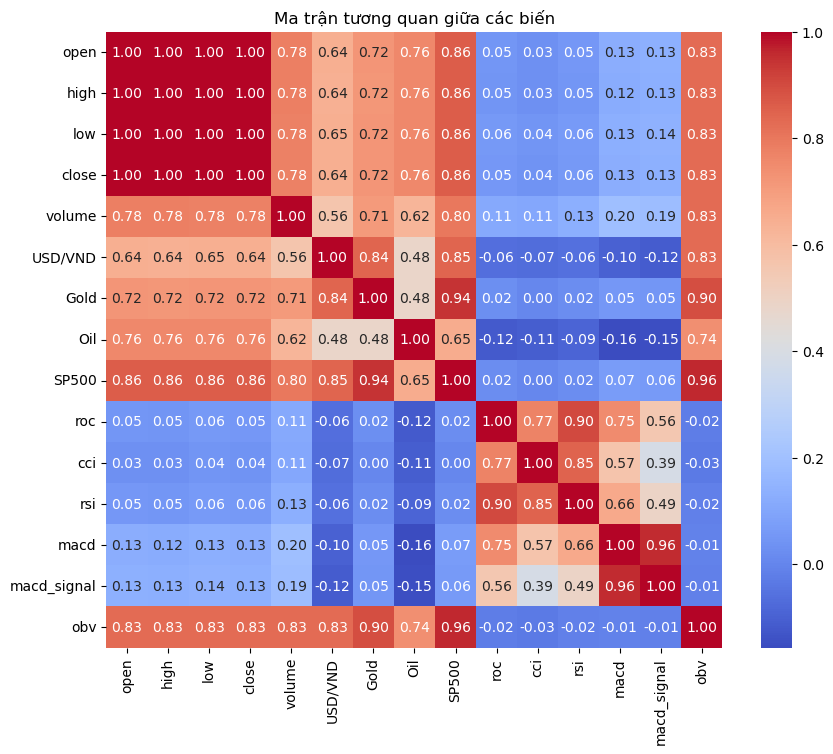

In [10]:
# Tính ma trận tương quan
corr_matrix = data.corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', square=True)
plt.title("Ma trận tương quan giữa các biến")
plt.show()

In [11]:
#loại bỏ các biến có tương quan cao
data_filtered = data.drop(columns=['open', 'high', 'low', 'macd_signal','obv'])

In [12]:
# Danh sách các cột cần tạo biến lag
cols_to_lag = ["close","volume","USD/VND", "Gold", "Oil", "SP500", "roc", "cci", "rsi", "macd"]
lags = [1,2,3,4,5]

data_lag = data_filtered.copy()

# Tạo biến lag cho từng cột và từng độ trễ
for col in cols_to_lag:
    for lag in lags:
        data_lag[f"{col}_lag{lag}"] = data_lag[col].shift(lag)

# Xoá các dòng chứa NaN sau khi tạo lag
data_lag = data_lag.dropna()#.reset_index(drop=True)
data_lag

,close,volume,USD/VND,Gold,Oil,SP500,roc,cci,rsi,macd,close_lag1,close_lag2,close_lag3,close_lag4,close_lag5,volume_lag1,volume_lag2,volume_lag3,volume_lag4,volume_lag5,USD/VND_lag1,USD/VND_lag2,USD/VND_lag3,USD/VND_lag4,USD/VND_lag5,Gold_lag1,Gold_lag2,Gold_lag3,Gold_lag4,Gold_lag5,Oil_lag1,Oil_lag2,Oil_lag3,Oil_lag4,Oil_lag5,SP500_lag1,SP500_lag2,SP500_lag3,SP500_lag4,SP500_lag5,roc_lag1,roc_lag2,roc_lag3,roc_lag4,roc_lag5,cci_lag1,cci_lag2,cci_lag3,cci_lag4,cci_lag5,rsi_lag1,rsi_lag2,rsi_lag3,rsi_lag4,rsi_lag5,macd_lag1,macd_lag2,macd_lag3,macd_lag4,macd_lag5
2015-02-09,573.550,62712850.000,20961.000,1240.800,52.860,2046.740,0.232,-10.016,50.986,3.432,574.130,567.170,561.450,557.470,570.370,58140870.000,69467520.000,90940000.000,93996200.000,66840420.000,20978.000,20979.000,21058.000,20973.000,20991.000,1233.900,1262.000,1263.800,1259.700,1276.200,51.690,50.480,48.450,53.050,49.570,2055.470,2062.520,2041.510,2050.030,2020.850,-0.118,-1.830,-2.697,-3.984,-0.688,-22.141,-78.050,-126.767,-71.966,16.122,49.510,41.920,37.123,30.735,46.302,3.470,3.408,3.989,5.254,7.198
2015-02-10,574.520,61234350.000,20970.000,1231.600,50.020,2068.590,0.949,12.560,54.135,3.441,573.550,574.130,567.170,561.450,557.470,62712850.000,58140870.000,69467520.000,90940000.000,93996200.000,20961.000,20978.000,20979.000,21058.000,20973.000,1240.800,1233.900,1262.000,1263.800,1259.700,52.860,51.690,50.480,48.450,53.050,2046.740,2055.470,2062.520,2041.510,2050.030,0.232,-0.118,-1.830,-2.697,-3.984,-10.016,-22.141,-78.050,-126.767,-71.966,50.986,49.510,41.920,37.123,30.735,3.432,3.470,3.408,3.989,5.254
2015-02-11,581.760,70560970.000,20968.000,1219.000,48.840,2068.530,1.257,61.799,55.378,3.987,574.520,573.550,574.130,567.170,561.450,61234350.000,62712850.000,58140870.000,69467520.000,90940000.000,20970.000,20961.000,20978.000,20979.000,21058.000,1231.600,1240.800,1233.900,1262.000,1263.800,50.020,52.860,51.690,50.480,48.450,2068.590,2046.740,2055.470,2062.520,2041.510,0.949,0.232,-0.118,-1.830,-2.697,12.560,-10.016,-22.141,-78.050,-126.767,54.135,50.986,49.510,41.920,37.123,3.441,3.432,3.470,3.408,3.989
2015-02-12,584.670,79108960.000,20943.000,1220.100,51.210,2088.480,0.393,109.140,51.841,4.600,581.760,574.520,573.550,574.130,567.170,70560970.000,61234350.000,62712850.000,58140870.000,69467520.000,20968.000,20970.000,20961.000,20978.000,20979.000,1219.000,1231.600,1240.800,1233.900,1262.000,48.840,50.020,52.860,51.690,50.480,2068.530,2068.590,2046.740,2055.470,2062.520,1.257,0.949,0.232,-0.118,-1.830,61.799,12.560,-10.016,-22.141,-78.050,55.378,54.135,50.986,49.510,41.920,3.987,3.441,3.432,3.470,3.408
2015-02-13,587.240,72295080.000,20986.000,1226.500,52.780,2096.990,1.137,136.263,55.236,5.234,584.670,581.760,574.520,573.550,574.130,79108960.000,70560970.000,61234350.000,62712850.000,58140870.000,20943.000,20968.000,20970.000,20961.000,20978.000,1220.100,1219.000,1231.600,1240.800,1233.900,51.210,48.840,50.020,52.860,51.690,2088.480,2068.530,2068.590,2046.740,2055.470,0.393,1.257,0.949,0.232,-0.118,109.140,61.799,12.560,-10.016,-22.141,51.841,55.378,54.135,50.986,49.510,4.600,3.987,3.441,3.432,3.470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-26,1326.090,672071249.000,25600.000,3020.900,69.650,5712.200,0.597,51.104,56.072,10.839,1331.920,1330.320,1321.880,1323.930,1324.630,772470386.000,737479570.000,673776859.000,783924251.000,768370525.000,25620.000,25585.000,25545.000,25535.000,25510.000,3023.700,3013.100,3018.200,3040.000,3035.900,69.000,69.110,68.280,68.260,67.160,5776.650,5767.570,5667.560,5662.890,5675.290,2.086,1.403,0.955,1.423,1.287,79.795,37.485,23.044,37.364,49.792,68.768,61.788,58.665,62.522,61.088,11.656,11.936,12.282,13.404,14.433
2025-03-27,1323.810,522142993.000,25555.000,3060.200,69.920,5693.310,-0.169,12.601,48.110,9.894,1326.090,1331.9

In [13]:
data_lag = data_lag.drop(columns=["volume","USD/VND", "Gold", "Oil", "SP500", "roc", "cci", "rsi", "macd"])
data_lag

,close,close_lag1,close_lag2,close_lag3,close_lag4,close_lag5,volume_lag1,volume_lag2,volume_lag3,volume_lag4,volume_lag5,USD/VND_lag1,USD/VND_lag2,USD/VND_lag3,USD/VND_lag4,USD/VND_lag5,Gold_lag1,Gold_lag2,Gold_lag3,Gold_lag4,Gold_lag5,Oil_lag1,Oil_lag2,Oil_lag3,Oil_lag4,Oil_lag5,SP500_lag1,SP500_lag2,SP500_lag3,SP500_lag4,SP500_lag5,roc_lag1,roc_lag2,roc_lag3,roc_lag4,roc_lag5,cci_lag1,cci_lag2,cci_lag3,cci_lag4,cci_lag5,rsi_lag1,rsi_lag2,rsi_lag3,rsi_lag4,rsi_lag5,macd_lag1,macd_lag2,macd_lag3,macd_lag4,macd_lag5
2015-02-09,573.550,574.130,567.170,561.450,557.470,570.370,58140870.000,69467520.000,90940000.000,93996200.000,66840420.000,20978.000,20979.000,21058.000,20973.000,20991.000,1233.900,1262.000,1263.800,1259.700,1276.200,51.690,50.480,48.450,53.050,49.570,2055.470,2062.520,2041.510,2050.030,2020.850,-0.118,-1.830,-2.697,-3.984,-0.688,-22.141,-78.050,-126.767,-71.966,16.122,49.510,41.920,37.123,30.735,46.302,3.470,3.408,3.989,5.254,7.198
2015-02-10,574.520,573.550,574.130,567.170,561.450,557.470,62712850.000,58140870.000,69467520.000,90940000.000,93996200.000,20961.000,20978.000,20979.000,21058.000,20973.000,1240.800,1233.900,1262.000,1263.800,1259.700,52.860,51.690,50.480,48.450,53.050,2046.740,2055.470,2062.520,2041.510,2050.030,0.232,-0.118,-1.830,-2.697,-3.984,-10.016,-22.141,-78.050,-126.767,-71.966,50.986,49.510,41.920,37.123,30.735,3.432,3.470,3.408,3.989,5.254
2015-02-11,581.760,574.520,573.550,574.130,567.170,561.450,61234350.000,62712850.000,58140870.000,69467520.000,90940000.000,20970.000,20961.000,20978.000,20979.000,21058.000,1231.600,1240.800,1233.900,1262.000,1263.800,50.020,52.860,51.690,50.480,48.450,2068.590,2046.740,2055.470,2062.520,2041.510,0.949,0.232,-0.118,-1.830,-2.697,12.560,-10.016,-22.141,-78.050,-126.767,54.135,50.986,49.510,41.920,37.123,3.441,3.432,3.470,3.408,3.989
2015-02-12,584.670,581.760,574.520,573.550,574.130,567.170,70560970.000,61234350.000,62712850.000,58140870.000,69467520.000,20968.000,20970.000,20961.000,20978.000,20979.000,1219.000,1231.600,1240.800,1233.900,1262.000,48.840,50.020,52.860,51.690,50.480,2068.530,2068.590,2046.740,2055.470,2062.520,1.257,0.949,0.232,-0.118,-1.830,61.799,12.560,-10.016,-22.141,-78.050,55.378,54.135,50.986,49.510,41.920,3.987,3.441,3.432,3.470,3.408
2015-02-13,587.240,584.670,581.760,574.520,573.550,574.130,79108960.000,70560970.000,61234350.000,62712850.000,58140870.000,20943.000,20968.000,20970.000,20961.000,20978.000,1220.100,1219.000,1231.600,1240.800,1233.900,51.210,48.840,50.020,52.860,51.690,2088.480,2068.530,2068.590,2046.740,2055.470,0.393,1.257,0.949,0.232,-0.118,109.140,61.799,12.560,-10.016,-22.141,51.841,55.378,54.135,50.986,49.510,4.600,3.987,3.441,3.432,3.470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-26,1326.090,1331.920,1330.320,1321.880,1323.930,1324.630,772470386.000,737479570.000,673776859.000,783924251.000,768370525.000,25620.000,25585.000,25545.000,25535.000,25510.000,3023.700,3013.100,3018.200,3040.000,3035.900,69.000,69.110,68.280,68.260,67.160,5776.650,5767.570,5667.560,5662.890,5675.290,2.086,1.403,0.955,1.423,1.287,79.795,37.485,23.044,37.364,49.792,68.768,61.788,58.665,62.522,61.088,11.656,11.936,12.282,13.404,14.433
2025-03-27,1323.810,1326.090,1331.920,1330.320,1321.880,1323.930,672071249.000,772470386.000,737479570.000,673776859.000,783924251.000,25600.000,25620.000,25585.000,25545.000,25535.000,3020.900,3023.700,3013.100,3018.200,3040.000,69.650,69.000,69.110,68.280,68.260,5712.200,5776.650,5767.570,5667.560,5662.890,0.597,2.086,1.403,0.955,1.423,51.104,79.795,37.485,23.044,37.364,56.072,68.768,61.788,58.665,62.522,10.839,11.656,11.936,12.282,13.404
2025-03-28,1317.460,1323.810,1326.090,1331.920,1330.320,1321.880,522142993.000,672071249.000,772470386.000,737479570.000,673776859.000,25555.000,25600.000,25620.000,25585.000,25545.000,3060.200,3020

In [14]:
# Tách features và target
X = data_lag.drop(columns=["close"])   # Dữ liệu đầu vào
y = data_lag["close"]                  # Biến mục tiêu

# Chia tập huấn luyện và kiểm tra (80/20) theo thời gian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [15]:
# Kiểm tra số lượng quan sát
print(f"Số quan sát tập huấn luyện: {X_train.shape[0]}")
print(f"Số quan sát tập kiểm tra: {X_test.shape[0]}")

Số quan sát tập huấn luyện: 1958
Số quan sát tập kiểm tra: 490


In [16]:
# Kiểm tra khoảng thời gian của mỗi tập
print(f"Khoảng thời gian tập huấn luyện: {X_train.index[0]} đến {X_train.index[-1]}")
print(f"Khoảng thời gian tập kiểm tra: {X_test.index[0]} đến {X_test.index[-1]}")

Khoảng thời gian tập huấn luyện: 2015-02-09 00:00:00 đến 2023-03-21 00:00:00
Khoảng thời gian tập kiểm tra: 2023-03-22 00:00:00 đến 2025-04-01 00:00:00


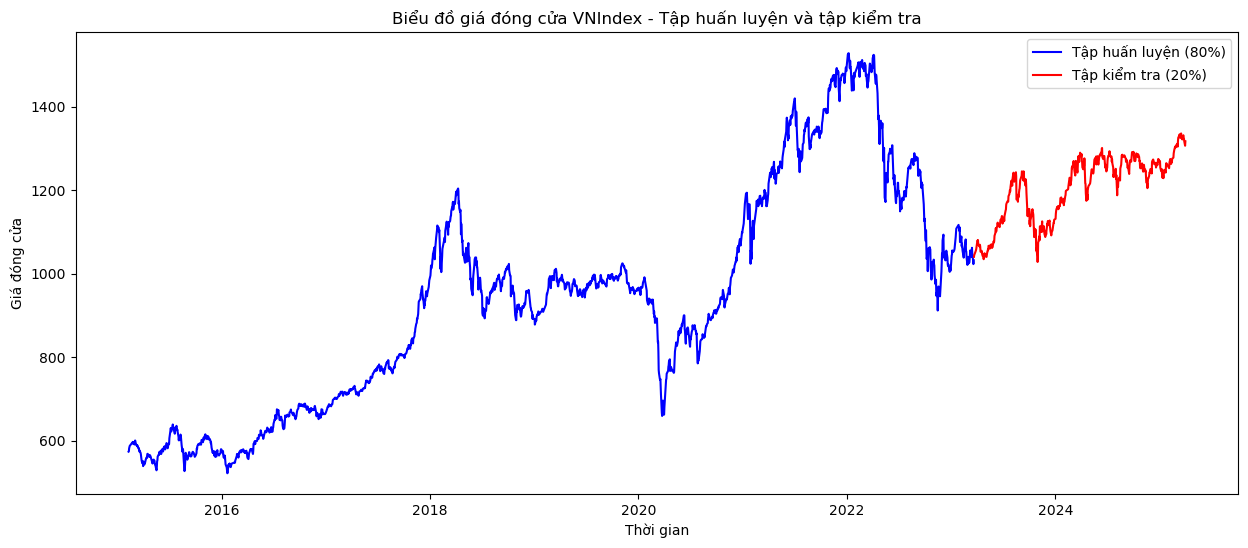

In [17]:
# Vẽ biểu đồ giá đóng cửa cho cả hai tập
plt.figure(figsize=(15, 6))
plt.plot(y_train.index, y_train, label='Tập huấn luyện (80%)', color='blue')
plt.plot(y_test.index, y_test, label='Tập kiểm tra (20%)', color='red')
plt.xlabel('Thời gian')
plt.ylabel('Giá đóng cửa')
plt.title('Biểu đồ giá đóng cửa VNIndex - Tập huấn luyện và tập kiểm tra')
plt.legend()
plt.show()

In [18]:
# Chuẩn hóa
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# Áp dụng scaler đã fit cho tập kiểm tra
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Sau khi chuẩn hóa, chuyển lại thành DataFrame có cột kiểu chuỗi
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns.astype(str), index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns.astype(str), index=X_test.index)

### Tạo hàm

In [19]:
# Hàm đánh giá mô hình
def model_evaluation(model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y):
    # Dự đoán trên tập huấn luyện và kiểm tra
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    #Đảo ngược chuẩn hóa
    y_train_pred = scaler_y.inverse_transform(y_train_pred.reshape(-1, 1))
    y_test_pred = scaler_y.inverse_transform(y_test_pred.reshape(-1, 1))

    # --- Train metrics ---
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # --- Test metrics ---
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # In kết quả
    print("---- Train Metrics ----")
    print(f"MSE: {mse_train:.3f}")
    print(f"RMSE: {rmse_train:.3f}")
    print(f"MAE: {mae_train:.3f}")
    print(f"R2: {r2_train:.3f}")

    print("\n---- Test Metrics ----")
    print(f"MSE: {mse_test:.3f}")
    print(f"RMSE: {rmse_test:.3f}")
    print(f"MAE: {mae_test:.3f}")
    print(f"R2: {r2_test:.3f}")

In [20]:
def plot_actual_predictive_data(model,y_test, X_test_scaled, scaler_y):
    # Vẽ biểu đồ
    plt.figure(figsize=(14,7))

    # Vẽ dữ liệu thực tế
    plt.plot(y_test.index, y_test, color='blue', label='Dữ liệu thực tế (tập test)', linestyle='--')

    # Vẽ dự đoán từ mô hình
    y_test_pred = model.predict(X_test_scaled)
    y_test_pred = scaler_y.inverse_transform(y_test_pred.reshape(-1, 1))
    plt.plot(y_test.index, y_test_pred, color='red', label='Dữ liệu dự đoán (tập test)', linestyle='-')

    # Thêm nhãn và tiêu đề
    plt.title("So sánh dữ liệu thực tế và dữ liệu dự đoán mô hình LR", fontsize=16)
    plt.xlabel('Thời gian', fontsize=12)
    plt.ylabel('Giá đóng cửa VNIndex', fontsize=12)

    # Định dạng lại trục x để dễ đọc (có thể cần điều chỉnh tùy theo số lượng ngày)
    plt.xticks()

    # Thêm legend
    plt.legend()

    # Hiển thị biểu đồ
    plt.tight_layout()
    plt.show()

### LinearRegression

In [21]:
model_LR = LinearRegression()
model_LR.fit(X_train_scaled, y_train_scaled)

LinearRegression()

In [22]:
model_evaluation(model_LR, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

---- Train Metrics ----
MSE: 133.556
RMSE: 11.557
MAE: 7.682
R2: 0.998

---- Test Metrics ----
MSE: 123.150
RMSE: 11.097
MAE: 8.115
R2: 0.981


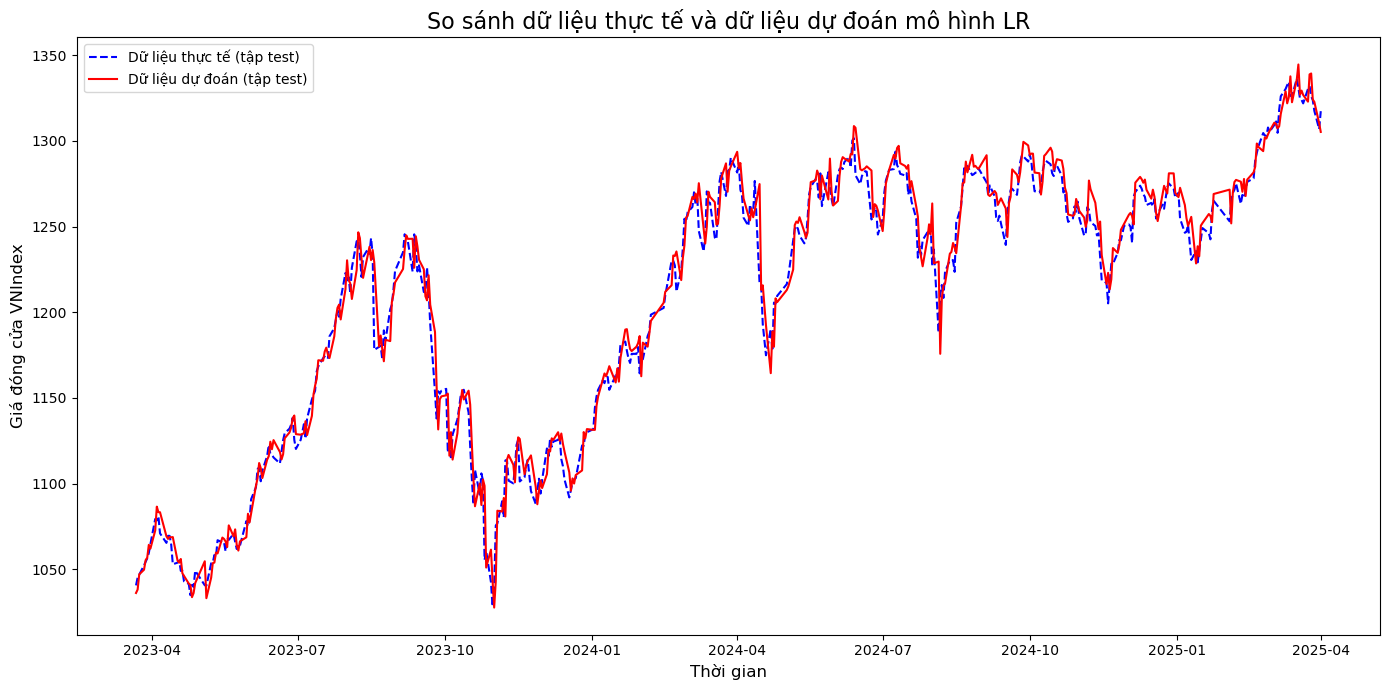

In [23]:
plot_actual_predictive_data(model_LR, y_test, X_test_scaled, scaler_y)

### SVR

In [75]:
# # Tập siêu tham số cần tìm
# param_grid_svr = {
#     'kernel': ['rbf', 'linear', 'poly'],       # loại kernel
#     'C': [0.1, 1, 10, 100],                    # hệ số điều chỉnh độ phạt
#     'epsilon': [0.01, 0.1, 0.2],               # sai số chấp nhận trong hàm mất mát
#     'gamma': ['scale', 'auto']                # hệ số kernel 
# }

# # GridSearchCV
# svr = SVR()
# grid_svr = GridSearchCV(estimator=svr, param_grid=param_grid_svr,
#                         cv=5, n_jobs=-1, scoring='neg_mean_squared_error', verbose=1)

# # Huấn luyện mô hình
# grid_svr.fit(X_train_scaled, y_train_scaled)

# # Kết quả tốt nhất
# print("Tham số SVR tốt nhất:", grid_svr.best_params_)

In [24]:
model_SVR = SVR(C=1, epsilon=0.01, gamma='scale', kernel='linear')

In [25]:
model_SVR.fit(X_train_scaled, y_train_scaled)

SVR(C=1, epsilon=0.01, kernel='linear')

In [26]:
model_evaluation(model_SVR, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

---- Train Metrics ----
MSE: 138.644
RMSE: 11.775
MAE: 7.836
R2: 0.998

---- Test Metrics ----
MSE: 129.769
RMSE: 11.392
MAE: 8.365
R2: 0.980


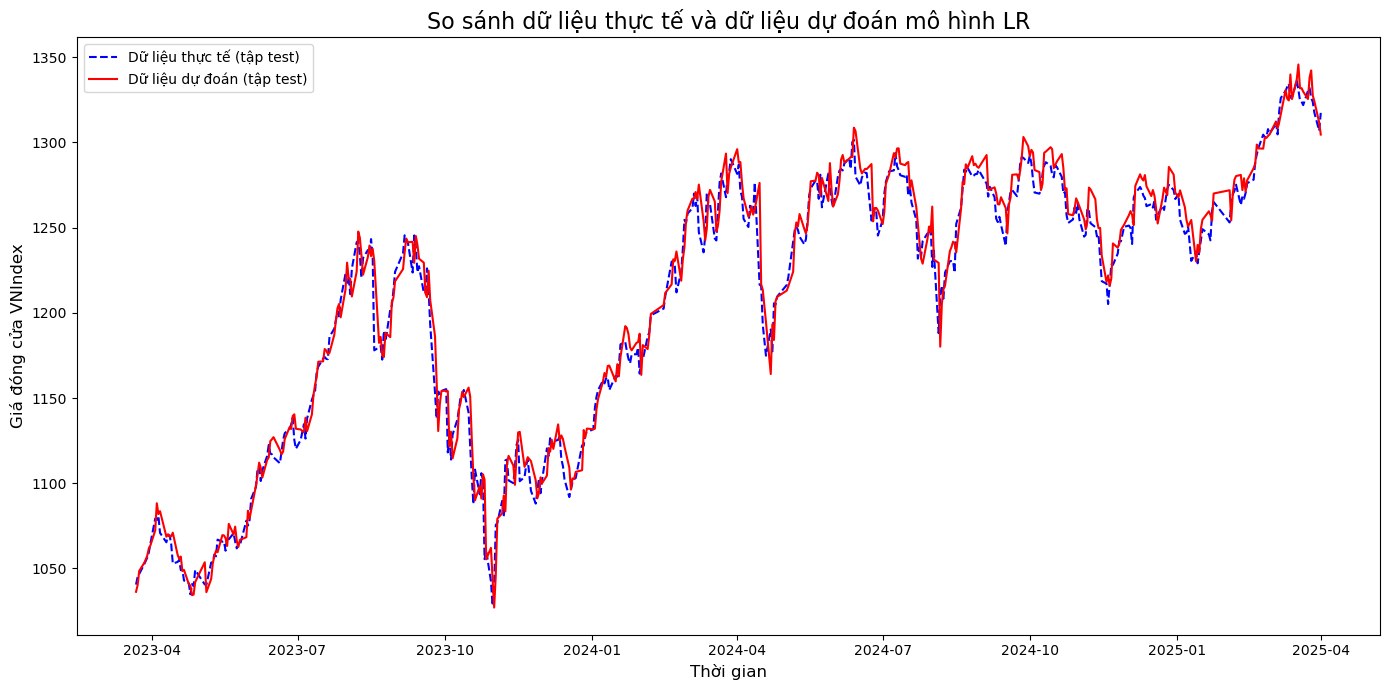

In [27]:
plot_actual_predictive_data(model_SVR, y_test, X_test_scaled, scaler_y)

### RF

In [80]:
# param_grid_rf = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# rf = RandomForestRegressor(random_state=1)
# grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
# grid_rf.fit(X_train_scaled, y_train_scaled)

# print("Tham số RF tốt nhất:", grid_rf.best_params_)

In [28]:
model_RF = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=2, random_state=1)

In [29]:
model_RF.fit(X_train_scaled, y_train_scaled)

RandomForestRegressor(max_depth=5, min_samples_leaf=2, random_state=1)

In [30]:
model_evaluation(model_RF, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

---- Train Metrics ----
MSE: 133.781
RMSE: 11.566
MAE: 7.966
R2: 0.998

---- Test Metrics ----
MSE: 148.322
RMSE: 12.179
MAE: 9.041
R2: 0.977


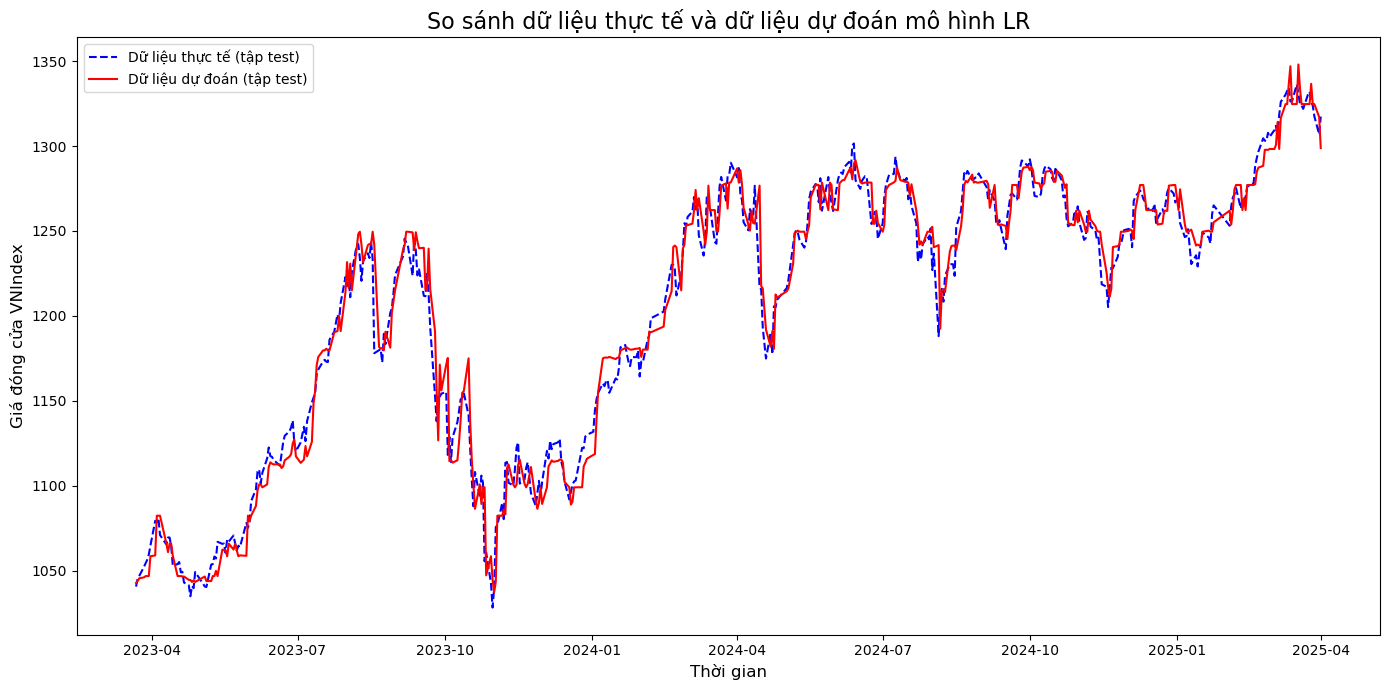

In [31]:
plot_actual_predictive_data(model_RF, y_test, X_test_scaled, scaler_y)

### XGBoost

In [85]:
# param_grid_xgb = {
#     'n_estimators': [100, 200, 300],           # số cây
#     'max_depth': [3, 5, 7],                    # độ sâu mỗi cây
#     'learning_rate': [0.01, 0.05, 0.1],        # tốc độ học
#     'subsample': [0.6, 0.8, 1.0],              # tỷ lệ mẫu dùng để huấn luyện mỗi cây
#     'colsample_bytree': [0.6, 0.8, 1.0],       # tỷ lệ cột được chọn cho mỗi cây
#     'reg_alpha': [0, 1, 2],                    # regularization L1
#     'reg_lambda': [0, 1, 2]                    # regularization L2
# }

# xgb = xgb.XGBRegressor(random_state=1, objective='reg:squarederror')
# grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
# grid_xgb.fit(X_train_scaled, y_train_scaled)

# print("Tham số XGB tốt nhất:", grid_xgb.best_params_)

In [32]:
model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=1,
    reg_lambda=0,
    random_state=1
)

In [33]:
model_xgb.fit(X_train_scaled, y_train_scaled)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
model_evaluation(model_xgb, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

---- Train Metrics ----
MSE: 133.404
RMSE: 11.550
MAE: 7.822
R2: 0.998

---- Test Metrics ----
MSE: 164.643
RMSE: 12.831
MAE: 9.445
R2: 0.974


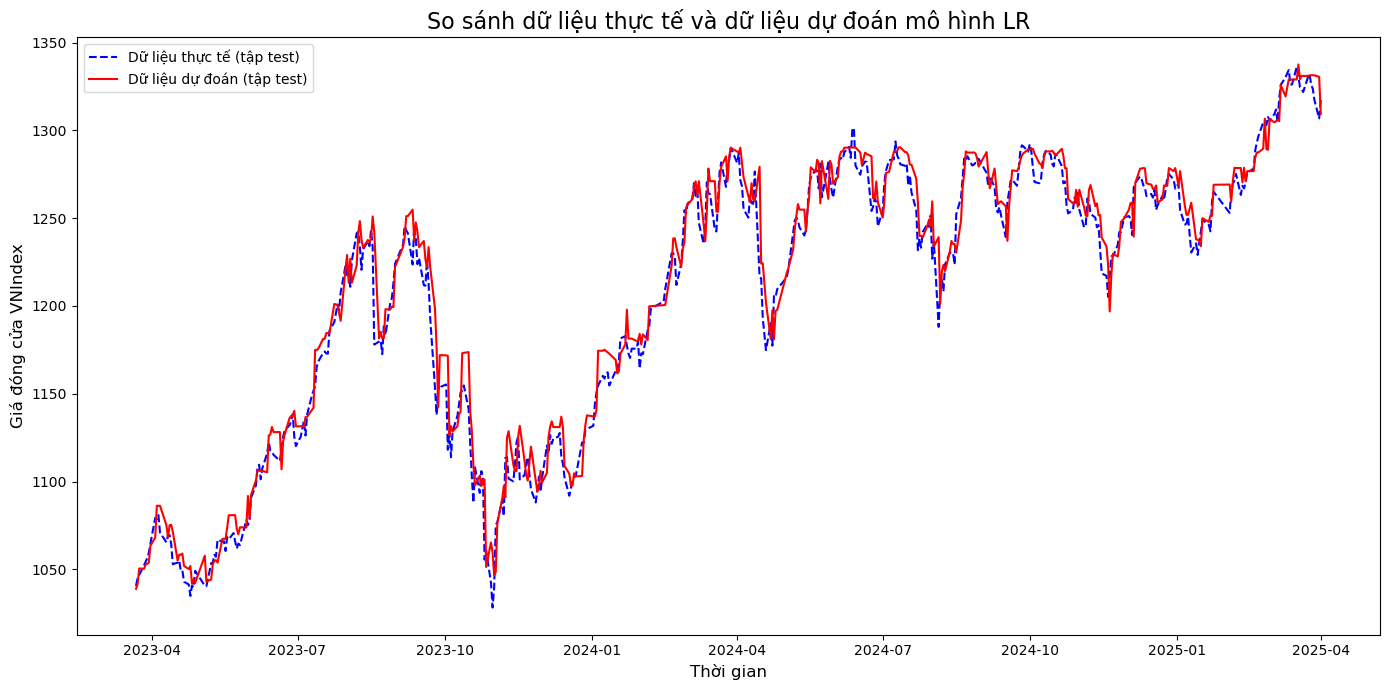

In [35]:
plot_actual_predictive_data(model_xgb, y_test, X_test_scaled, scaler_y)

### LightGBM

In [90]:
# param_grid_lgb = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],                    
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0],
#     'reg_alpha': [0, 1, 2],
#     'reg_lambda': [0, 1, 2]
# }
# lgb = lgb.LGBMRegressor(random_state=1)
# grid_lgb = GridSearchCV(lgb, param_grid_lgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
# grid_lgb.fit(X_train_scaled, y_train_scaled)

# print("Tham số LGBM tốt nhất:", grid_lgb.best_params_)

In [36]:
model_lgb = LGBMRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=1, 
    reg_lambda=1,
    random_state=1)

In [37]:
model_lgb.fit(X_train_scaled, y_train_scaled)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.077179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 1958, number of used features: 50
[LightGBM] [Info] Start training from score 0.410454
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMRegressor(max_depth=3, random_state=1, reg_alpha=1, reg_lambda=1)

In [38]:
model_evaluation(model_lgb, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

---- Train Metrics ----
MSE: 139.868
RMSE: 11.827
MAE: 7.983
R2: 0.998

---- Test Metrics ----
MSE: 145.299
RMSE: 12.054
MAE: 8.802
R2: 0.977


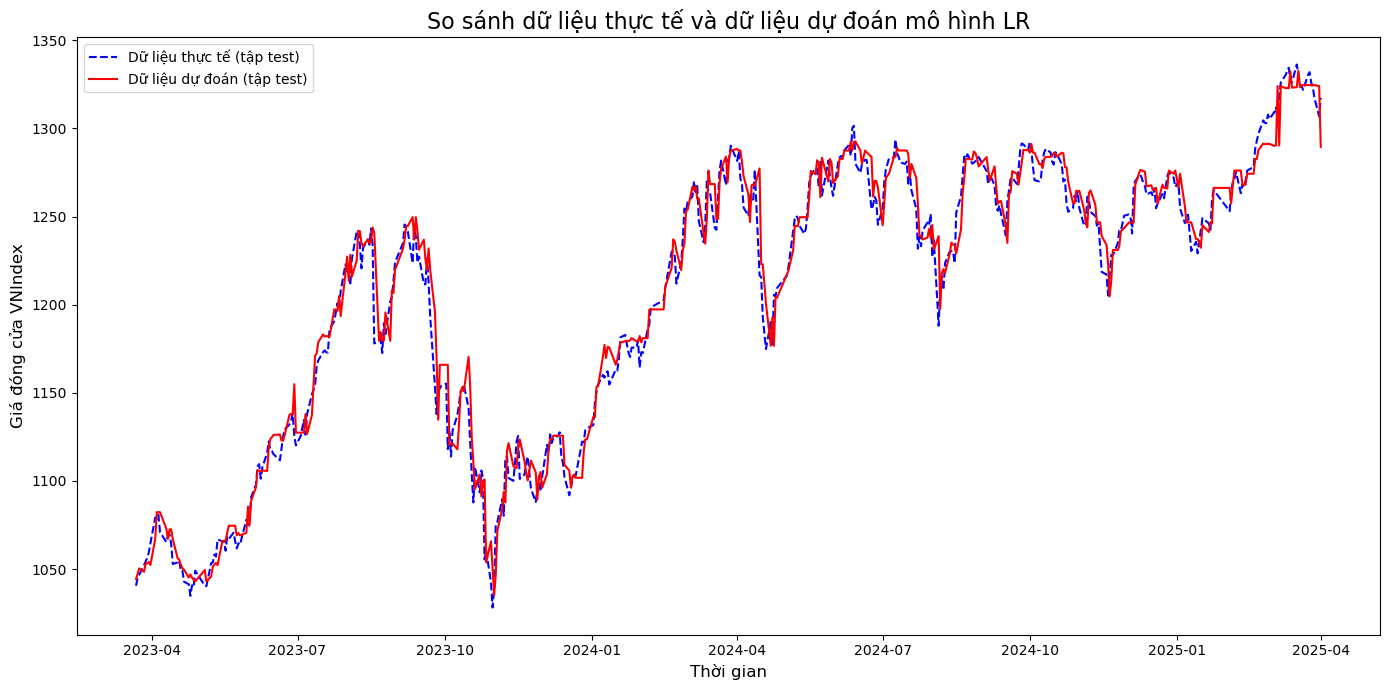

In [39]:
plot_actual_predictive_data(model_lgb, y_test, X_test_scaled, scaler_y)

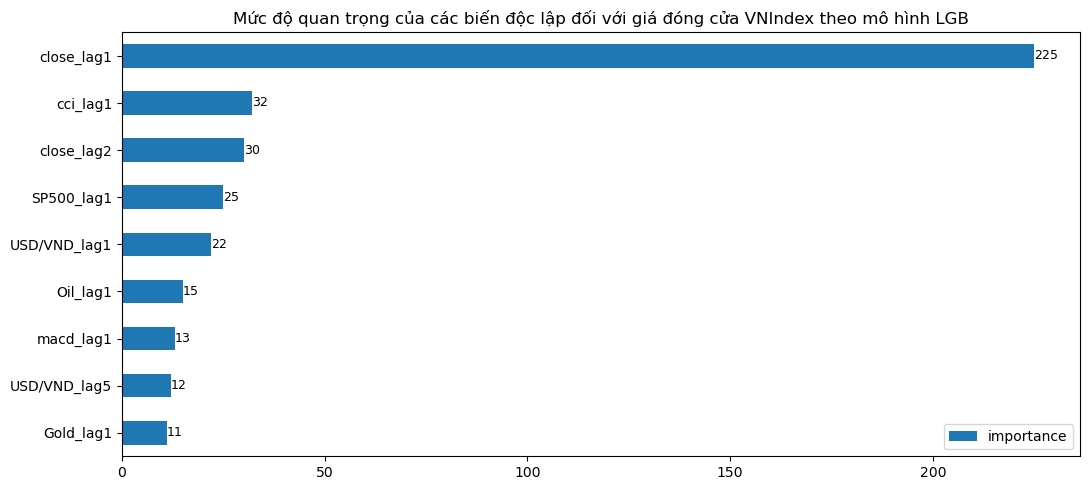

In [40]:
fi=pd.DataFrame(data=model_lgb.feature_importances_,
             index=model_lgb.feature_names_in_,
             columns=['importance'])

fi_filtered = fi[fi['importance'] > 10]  # chỉ hiện thị các biến có độ quan trọng trên 10

# Vẽ biểu đồ
ax = fi_filtered.sort_values('importance').plot(kind='barh', title='Mức độ quan trọng của các biến độc lập đối với giá đóng cửa VNIndex theo mô hình LGB', figsize=(11, 5))

# Thêm số cụ thể tại mỗi thanh
for i, v in enumerate(fi_filtered.sort_values('importance')['importance']):
    ax.text(v, i, f"{v}", va='center', fontsize=9)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

## Dự báo đa bước

In [41]:
df = data_lag.copy()

# Chia dữ liệu 
size = int(len(df) * 0.95)
df_train = df.iloc[:size]
df_test = df.iloc[size:]

In [42]:
from sklearn.base import clone
def multi_step_prediction_evaluate(model, df_train, df_test):
    start = time.time()

    max_forecast_horizon = len(df_test)

    # Lấy các cột lag
    X_cols = [col for col in df_train.columns if '_lag' in col]

    # Scale X chung (ổn định hơn)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    # Fit scaler trên toàn bộ train
    X_scaled_full = scaler_X.fit_transform(df_train[X_cols])
    y_scaled_full = scaler_y.fit_transform(df_train[['close']])

    models = {}

    # Train model cho từng step (DIRECT STRATEGY)
    for step in range(1, max_forecast_horizon + 1):
        df_data = df_train.copy()

        # tạo target tương lai
        df_data[f'target_t+{step}'] = df_data['close'].shift(-step)
        df_data = df_data.dropna()

        X = df_data[X_cols]
        y = df_data[f'target_t+{step}']

        # scale
        X_scaled = scaler_X.transform(X)
        y_scaled = scaler_y.transform(y.values.reshape(-1, 1))

        # clone model 
        model_step = clone(model)
        model_step.fit(X_scaled, y_scaled.ravel())

        models[step] = model_step

    # Dự báo từ điểm cuối
    X_last = df_train[X_cols].iloc[[-1]]
    X_last_scaled = scaler_X.transform(X_last)

    preds = []

    for step in range(1, max_forecast_horizon + 1):
        model_step = models[step]

        y_pred_scaled = model_step.predict(X_last_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))[0, 0]

        preds.append(y_pred)

    pred_future = np.array(preds)

    # Ground truth
    true_future = df_test['close'].values

    # đảm bảo cùng length
    min_len = min(len(pred_future), len(true_future))
    pred_future = pred_future[:min_len]
    true_future = true_future[:min_len]

    # Metrics
    mse = mean_squared_error(true_future, pred_future)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true_future, pred_future)
    r2 = r2_score(true_future, pred_future)

    end = time.time()
    elapsed_time = end - start

    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R2: {r2:.3f}")
    print(f"Time: {elapsed_time:.3f}s")

    return pred_future, true_future

In [43]:
#Linear Regression
pred_future_LR, true_future_LR=multi_step_prediction_evaluate(LinearRegression(), df_train, df_test)

MSE: 24663.081
RMSE: 157.045
MAE: 139.493
R2: -26.130
Time: 6.970s


In [44]:
# SVR
pred_future_SVR, true_future_SVR=multi_step_prediction_evaluate(SVR(C=1, epsilon=0.01, gamma='scale', kernel='linear'), df_train, df_test)

MSE: 39634.487
RMSE: 199.084
MAE: 177.189
R2: -42.599
Time: 108.799s


In [45]:
#Random Forest
pred_future_RF, true_future_RF=multi_step_prediction_evaluate(RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=2, random_state=1), df_train, df_test)

MSE: 1096.198
RMSE: 33.109
MAE: 25.080
R2: -0.206
Time: 791.007s


In [46]:
#XGBoost
pred_future_xgb, true_future_xgb=multi_step_prediction_evaluate(XGBRegressor(n_estimators=100,learning_rate=0.1, max_depth=3,subsample=1.0,colsample_bytree=1.0,reg_alpha=1,reg_lambda=0,random_state=1), df_train, df_test)

MSE: 662.056
RMSE: 25.730
MAE: 20.315
R2: 0.272
Time: 36.722s


In [47]:
#LightGBM
pred_future_lgb, true_future_lgb=multi_step_prediction_evaluate(LGBMRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=1.0,colsample_bytree=1.0,reg_alpha=0,reg_lambda=0,random_state=1), df_train, df_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 2324, number of used features: 50
[LightGBM] [Info] Start training from score 0.449313
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

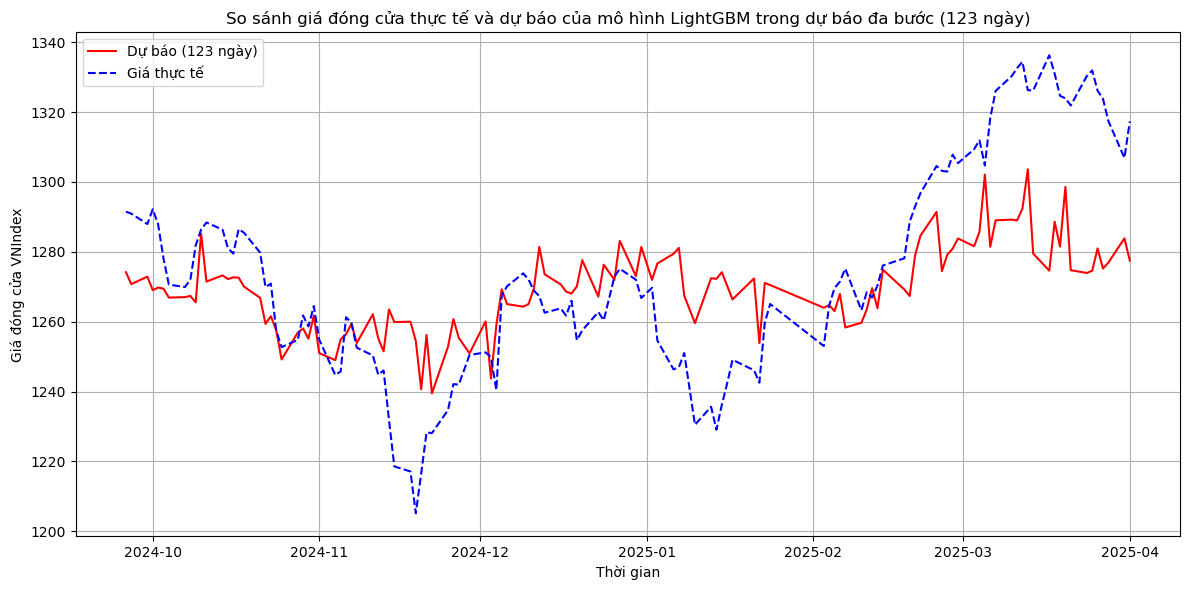

In [48]:
#trực quan hóa giá trị dự đoán và thực tế cho mô hình có kết quả tốt nhất (multi-step)
plt.figure(figsize=(12, 6))

# Vẽ dữ liệu dự báo và thực tế
plt.plot(df_test.index, pred_future_lgb, label='Dự báo (123 ngày)', color='red')
plt.plot(df_test.index, true_future_lgb, label='Giá thực tế', color='blue', linestyle='--')
#plt.plot(df.index, df['close'], label='Giá thực tế', color='blue', linestyle='--')

# Chú thích
plt.title('So sánh giá đóng cửa thực tế và dự báo của mô hình LightGBM trong dự báo đa bước (123 ngày)')
plt.xlabel('Thời gian')
plt.ylabel('Giá đóng cửa VNIndex')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()